<a href="https://colab.research.google.com/github/oni-swr/bvh-mocap-via-video/blob/main/eccv22_demo/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
from pathlib import Path
path='../model'
#p = Path(path)
#if p.exists():
#    print(p.read_text())
model = tf.saved_model.load('../model')  # Takes about 3 minutes
#model = hub.load('https://bit.ly/metrabs_l')  # Takes about 3 minutes


img = tf.image.decode_image(tf.io.read_file('../images/360_F_142520188_1zrk4OedvlbBFg0LjCZgD8g9PNNaYa7Q.jpg'))


2025-10-27 12:44:31.442227: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
pred = model.detect_poses(img, skeleton='smpl+head_30')
pred['poses3d'].shape

TensorShape([2, 30, 3])

In [16]:
import os
print(os.getcwd())

print(os.listdir("../model"))
print(os.listdir("../model/variables"))

/Users/lino/Coding/bvh-mocap-via-video/eccv22_demo
['metrabs_eff2l_y4_384px_800k_28ds.tar.gz', 'variables', 'saved_model.pb', 'assets']
['variables.data-00000-of-00001', 'variables.index']


In [3]:
def plot_results(image, pred, joint_names, joint_edges):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from matplotlib.patches import Rectangle
    fig = plt.figure(figsize=(10, 5.2))
    image_ax = fig.add_subplot(1, 2, 1)
    image_ax.imshow(image.numpy())
    for x, y, w, h, c in pred['boxes'].numpy():
        image_ax.add_patch(Rectangle((x, y), w, h, fill=False))

    pose_ax = fig.add_subplot(1, 2, 2, projection='3d')
    pose_ax.view_init(5, -75)
    pose_ax.set_xlim3d(-1500, 1500)
    pose_ax.set_zlim3d(-1500, 1500)
    pose_ax.set_ylim3d(2000, 5000)
    poses3d = pred['poses3d'].numpy()
    poses3d[..., 1], poses3d[..., 2] = poses3d[..., 2], -poses3d[..., 1]
    for pose3d, pose2d in zip(poses3d, pred['poses2d'].numpy()):
        for i_start, i_end in joint_edges:
            image_ax.plot(*zip(pose2d[i_start], pose2d[i_end]), marker='o', markersize=2)
            pose_ax.plot(*zip(pose3d[i_start], pose3d[i_end]), marker='o', markersize=2)
        image_ax.scatter(*pose2d.T, s=2)
        pose_ax.scatter(*pose3d.T, s=2)

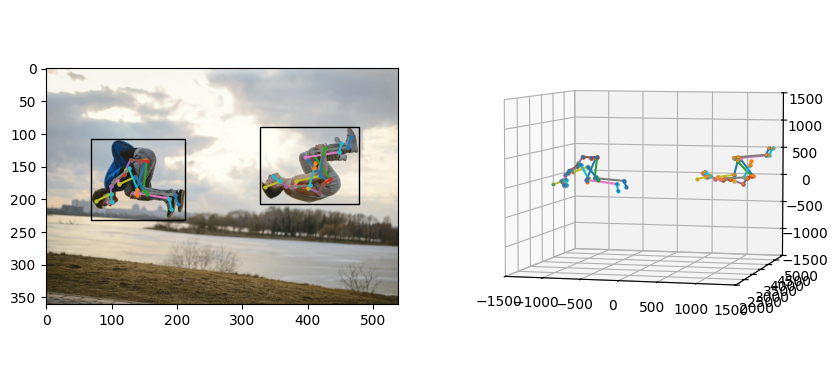

In [4]:
joint_names = model.per_skeleton_joint_names['smpl+head_30'].numpy().astype(str)
joint_edges = model.per_skeleton_joint_edges['smpl+head_30'].numpy()
plot_results(img, pred, joint_names, joint_edges)